In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
# Load the dataset

path = ("C:/Users/satish/Downloads/intern_task-5/train.csv")

df = pd.read_csv(path)

print(df)

     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     ...   ... 

In [16]:
# Basic Exploration of dataset

print("\nData Information:")
print(df.info())
print("*"*100)

print("\nData Description:")
print(df.describe())
print("*"*100)

print("\nValue Counts For 'Survived':")
print(df["Survived"].value_counts())
print("Here '0' refers Died")
print("Here '1' refers Alive")


Data Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
****************************************************************************************************

Data Description:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000

In [17]:
# Checking the Missing Values

print("\nMissing Values Before Replacement")
print(df.isna().sum())


Missing Values Before Replacement
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [18]:
# Here Age, Cabin and Embarked has missing values

In [19]:
# Replace Missing Values
# For Age replace with median

df["Age"] = df["Age"].fillna(df["Age"].median())

In [20]:
# For Embraked replace with mode

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [21]:
# For Cabin replace with 

df["Cabin"] = df["Cabin"].fillna("Unknown")

In [22]:
# Checking missing values for filling the values

df.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [23]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

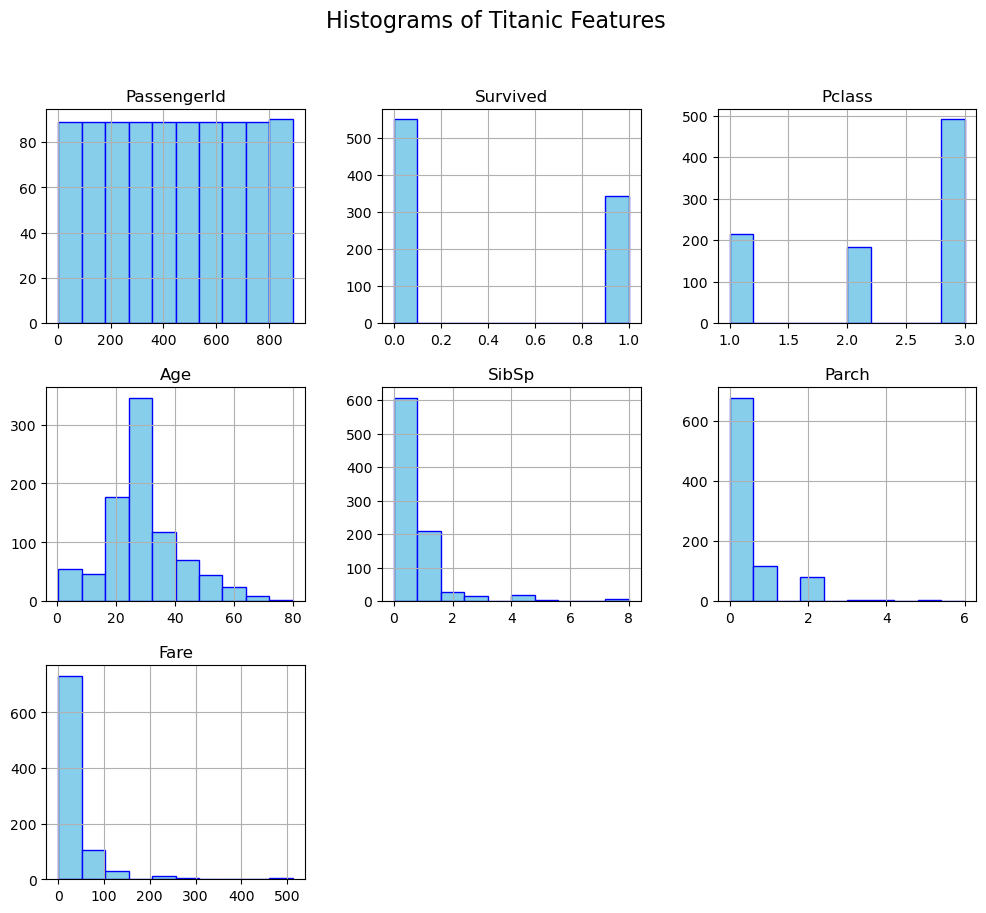

In [24]:
# Data Visualization using Matplotlib and seaborn

# Histogram 

df.hist(figsize = (12, 10), color = 'skyblue', edgecolor = 'blue')
plt.suptitle('Histograms of Titanic Features', fontsize = 16)
plt.show()

In [69]:
# Observation 1: PassengerId distribution
print("PassengerId is uniformly distributed.")
print("*"*120)

# Observation 2: Survived distribution
survival_counts = df['Survived'].value_counts()
print("\nSurvival Counts:\n", survival_counts)
if survival_counts[0] > survival_counts[1]:
    print("More passengers did NOT survive.")
else:
    print("More passengers survived.")
print("*"*120)

# Observation 3: Pclass distribution
pclass_counts = df['Pclass'].value_counts()
print("\nPassenger Class Counts:\n", pclass_counts)
print(f"Most passengers belong to class {pclass_counts.idxmax()}.")
print("*"*120)

# Observation 4: Age distribution
print("\nAge Statistics:")
print(df['Age'].describe())
print("Most passengers are between 20 and 40 years old.")
print("*"*120)

# Observation 5: SibSp distribution
sibsp_counts = df['SibSp'].value_counts()
print("\nSibSp (Siblings/Spouses aboard) Counts:\n", sibsp_counts)
print("Most passengers had no siblings or spouses aboard.")
print("*"*120)

# Observation 6: Parch distribution
parch_counts = df['Parch'].value_counts()
print("\nParch (Parents/Children aboard) Counts:\n", parch_counts)
print("Most passengers had no parents or children aboard.")
print("*"*120)

# Observation 3: Fare distribution
print("Fare distribution is right-skewed, with most fares under $100 and a few outliers with very high fares.")

PassengerId is uniformly distributed.
************************************************************************************************************************

Survival Counts:
 Survived
0    549
1    342
Name: count, dtype: int64
More passengers did NOT survive.
************************************************************************************************************************

Passenger Class Counts:
 Pclass
3    491
1    216
2    184
Name: count, dtype: int64
Most passengers belong to class 3.
************************************************************************************************************************

Age Statistics:
count    891.000000
mean      29.361582
std       13.019697
min        0.420000
25%       22.000000
50%       28.000000
75%       35.000000
max       80.000000
Name: Age, dtype: float64
Most passengers are between 20 and 40 years old.
************************************************************************************************************************


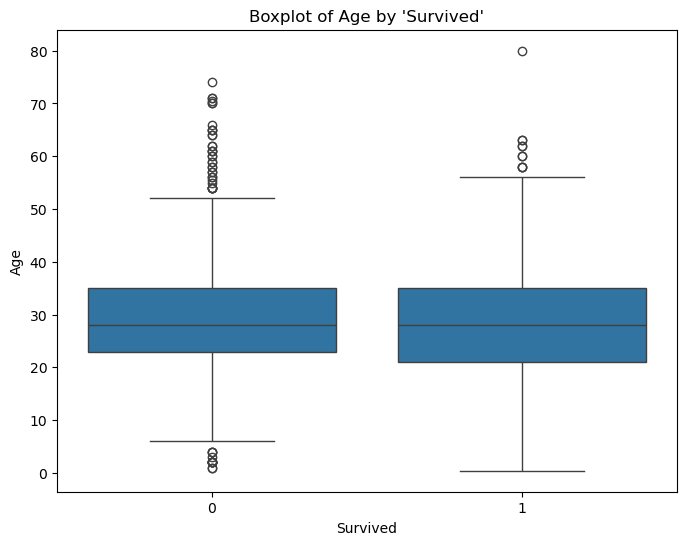

Here '0' refers Died
Here '1' refers Alive


In [25]:
# Boxplots

plt.figure(figsize = (8,6))
sns.boxplot(x = 'Survived', y = 'Age', data = df)
plt.title("Boxplot of Age by 'Survived'")
plt.show()
print("Here '0' refers Died")
print("Here '1' refers Alive")

In [73]:
# Observations
died_age_stats = df[df['Survived'] == 0]['Age'].describe()
survived_age_stats = df[df['Survived'] == 1]['Age'].describe()

print("Age Statistics for passengers who died (Survived=0):")
print(died_age_stats)
print("*"*120)

print("\nAge Statistics for passengers who survived (Survived=1):")
print(survived_age_stats)
print("*"*120)

# Example insights:
if died_age_stats['mean'] > survived_age_stats['mean']:
    print("\nObservation: On average, passengers who died were older than those who survived.")
else:
    print("\nObservation: On average, passengers who survived were older than those who died.")

if died_age_stats['25%'] > survived_age_stats['25%']:
    print("Younger passengers were more likely to survive.")
else:
    print("Survivors include many young passengers.")

Age Statistics for passengers who died (Survived=0):
count    549.000000
mean      30.028233
std       12.499986
min        1.000000
25%       23.000000
50%       28.000000
75%       35.000000
max       74.000000
Name: Age, dtype: float64
************************************************************************************************************************

Age Statistics for passengers who survived (Survived=1):
count    342.000000
mean      28.291433
std       13.764425
min        0.420000
25%       21.000000
50%       28.000000
75%       35.000000
max       80.000000
Name: Age, dtype: float64
************************************************************************************************************************

Observation: On average, passengers who died were older than those who survived.
Younger passengers were more likely to survive.


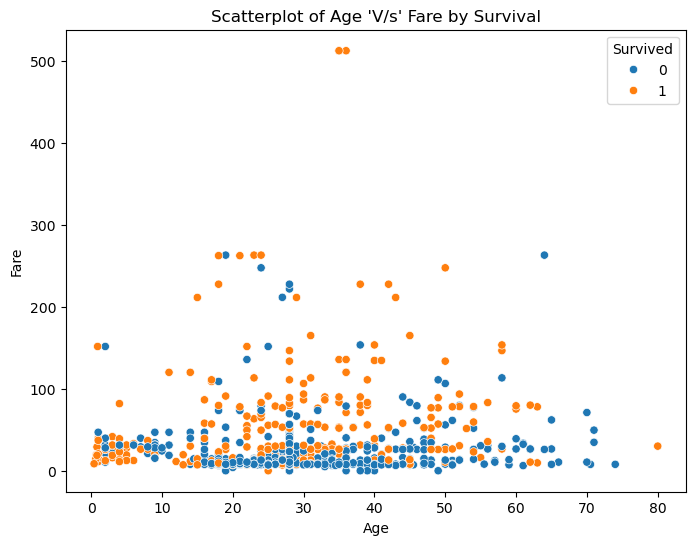

Here '0' refers Died
Here '1' refers Alive


In [30]:
# ScatterPlot

plt.figure(figsize = (8,6))
sns.scatterplot(x = 'Age', y = 'Fare', hue = 'Survived', data = df)
plt.title("Scatterplot of Age 'V/s' Fare by Survival")
plt.show()
print("Here '0' refers Died")
print("Here '1' refers Alive")

In [82]:
# Observations
print("Observations:")
print("1. Majority of passengers paid fare below 100.")
print("2. Younger passengers (age < 15) have a higher survival rate (more orange dots).")
print("3. High fare passengers (fare > 200) show more survival cases (orange).")
print("4. Elderly passengers (age > 60) have mixed survival outcomes.")
print("5. Survival seems more frequent in passengers with moderate age and higher fare.")

# Optional: You can break this down into more analytical code if needed.

Observations:
1. Majority of passengers paid fare below 100.
2. Younger passengers (age < 15) have a higher survival rate (more orange dots).
3. High fare passengers (fare > 200) show more survival cases (orange).
4. Elderly passengers (age > 60) have mixed survival outcomes.
5. Survival seems more frequent in passengers with moderate age and higher fare.


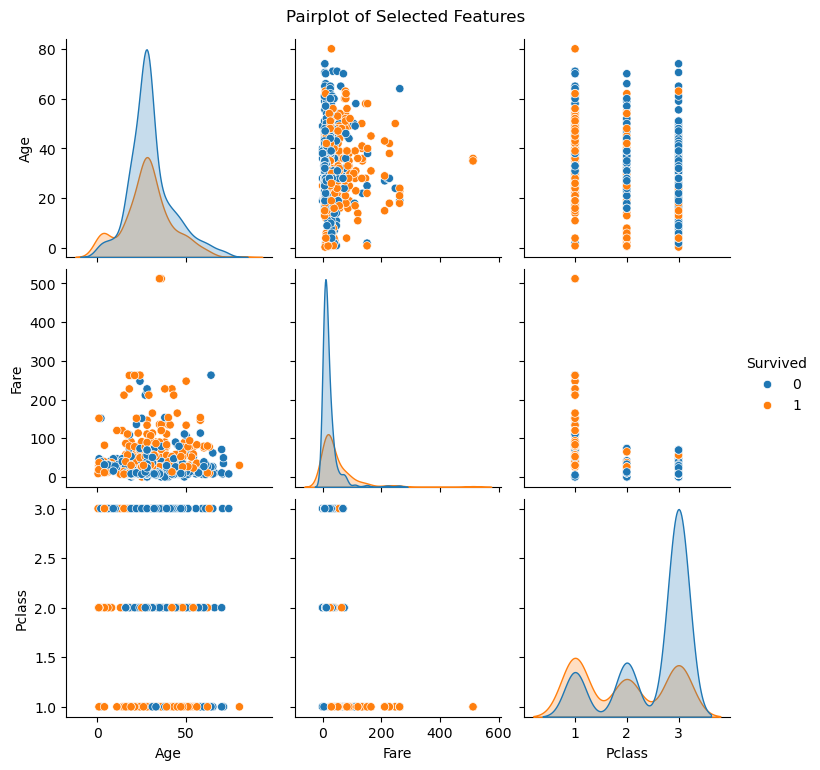

In [27]:
# Pairplot

sns.pairplot(df[['Survived', 'Age', 'Fare', 'Pclass']], hue = 'Survived')
plt.suptitle("Pairplot of Selected Features", y =  1.02)
plt.show()

In [81]:
# Observations based on the pairplot
observations = """
1. Fare vs Pclass: Passengers in lower classes (e.g., Pclass 3) generally paid lower fares, while higher class passengers (Pclass 1) paid more.
2. Fare vs Survived: Survived passengers tend to have paid higher fares, indicating a potential survival advantage for wealthier passengers.
3. Age Distribution: There is no clear age boundary for survival, but many survivors are observed in younger age ranges.
4. Pclass vs Survived: Higher survival rate is seen in Pclass 1 compared to Pclass 3, suggesting class significantly impacted survival.
5. Age vs Fare: No strong correlation, but most passengers who paid high fares were also from a smaller age group (middle-aged).
"""

print("Observations from the pairplot:")
print(observations)

Observations from the pairplot:

1. Fare vs Pclass: Passengers in lower classes (e.g., Pclass 3) generally paid lower fares, while higher class passengers (Pclass 1) paid more.
2. Fare vs Survived: Survived passengers tend to have paid higher fares, indicating a potential survival advantage for wealthier passengers.
3. Age Distribution: There is no clear age boundary for survival, but many survivors are observed in younger age ranges.
4. Pclass vs Survived: Higher survival rate is seen in Pclass 1 compared to Pclass 3, suggesting class significantly impacted survival.
5. Age vs Fare: No strong correlation, but most passengers who paid high fares were also from a smaller age group (middle-aged).



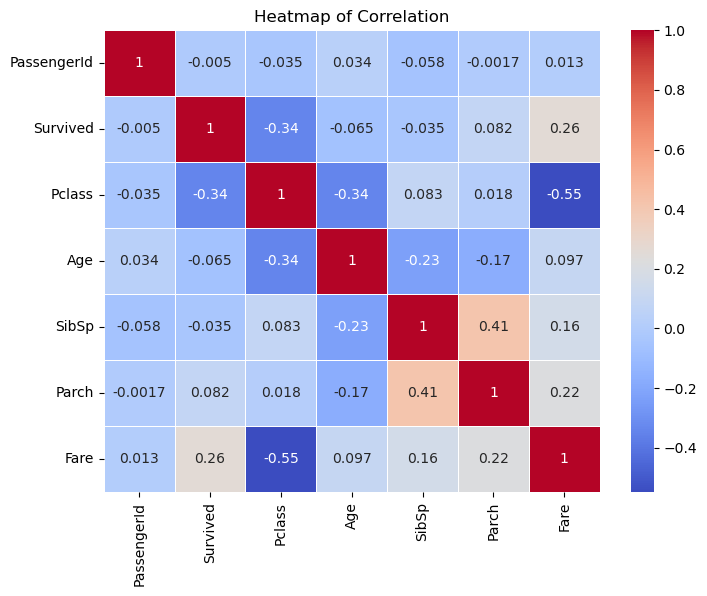

In [77]:
# Heatmap (Correlation)
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include=['float64', 'int64']).corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Heatmap of Correlation")
plt.show()

In [79]:
#Observations
print("\nKey Observations:")
# Top positively correlated with 'Survived'
print("1. Survived is moderately positively correlated with Fare (0.26).")
print("2. Survived has weak positive correlation with Parch (0.082).")
# Top negatively correlated with 'Survived'
print("3. Survived is moderately negatively correlated with Pclass (-0.34).")
print("4. Survived has weak negative correlation with Age (-0.065).")
# Other noticeable correlations
print("5. Pclass and Fare have a strong negative correlation (-0.55).")
print("6. SibSp and Parch show a moderate positive correlation (0.41).")


Key Observations:
1. Survived is moderately positively correlated with Fare (0.26).
2. Survived has weak positive correlation with Parch (0.082).
3. Survived is moderately negatively correlated with Pclass (-0.34).
4. Survived has weak negative correlation with Age (-0.065).
5. Pclass and Fare have a strong negative correlation (-0.55).
6. SibSp and Parch show a moderate positive correlation (0.41).


In [61]:
# Observations (printed directly here)
observations = """
Observations:
- Survival Rate: More people did not survive (0) compared to survivors (1).
- Missing Values: After replacement, no missing values remain.
- Age: Younger passengers had slightly higher survival rates.
- Fare: Higher fare seems associated with higher survival.
- Pclass: Lower class (higher number) had lower survival rates.
- Correlations: Fare and Pclass negatively correlated; Survived positively correlated with Fare.
"""
print(observations)

# Summary
summary = """
Summary of Findings:
- Younger and wealthier passengers had higher survival probabilities.
- First class passengers survived more compared to second and third classes.
- Age and Fare show some positive correlation with survival.
- Missing values have been handled properly.
- Fare is skewed; could consider transformations.
"""
print(summary)


Observations:
- Survival Rate: More people did not survive (0) compared to survivors (1).
- Missing Values: After replacement, no missing values remain.
- Age: Younger passengers had slightly higher survival rates.
- Fare: Higher fare seems associated with higher survival.
- Pclass: Lower class (higher number) had lower survival rates.
- Correlations: Fare and Pclass negatively correlated; Survived positively correlated with Fare.


Summary of Findings:
- Younger and wealthier passengers had higher survival probabilities.
- First class passengers survived more compared to second and third classes.
- Age and Fare show some positive correlation with survival.
- Missing values have been handled properly.
- Fare is skewed; could consider transformations.

